### Welcome to the exercise about observational studies! This exercise will be hands on, and you will be able to practise the skills you developed so far!

## Propensity score matching

In this exercise, you will apply [propensity score matching](http://www.stewartschultz.com/statistics/books/Design%20of%20observational%20studies.pdf), which we discussed in lecture 6 ("Observational studies"), in order to draw conclusions from an observational study.

We will work with a by-now classic dataset from Robert LaLonde's study "[Evaluating the Econometric Evaluations of Training Programs](http://people.hbs.edu/nashraf/LaLonde_1986.pdf)" (1986).
The study investigated the effect of a job training program ("National Supported Work Demonstration") on the real earnings of an individual, a couple of years after completion of the program.
Your task is to determine the effectiveness of the "treatment" represented by the job training program.

#### Dataset description

- `treat`: 1 if the subject participated in the job training program, 0 otherwise
- `age`: the subject's age
- `educ`: years of education
- `race`: categorical variable with three possible values: Black, Hispanic, or White
- `married`: 1 if the subject was married at the time of the training program, 0 otherwise
- `nodegree`: 1 if the subject has earned no school degree, 0 otherwise
- `re74`: real earnings in 1974 (pre-treatment)
- `re75`: real earnings in 1975 (pre-treatment)
- `re78`: real earnings in 1978 (outcome)

If you want to deepen your knowledge on propensity scores and observational studies, we highly recommend Rosenbaum's excellent book on the ["Design of Observational Studies"](http://www.stewartschultz.com/statistics/books/Design%20of%20observational%20studies.pdf). Even just reading the first chapter (18 pages) will help you a lot.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
%matplotlib inline

data_folder = './data/'
df = pd.read_csv(data_folder + 'lalonde.csv')

In [2]:
df.sample(10)

,id,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
559,PSID375,0,46,11,1,0,1,1,0.000,0.0000,2820.980
356,PSID172,0,39,7,0,0,0,1,7786.126,1844.0320,9206.237
131,NSW132,1,28,11,1,0,0,1,0.000,1284.0790,60307.930
215,PSID31,0,22,13,0,1,0,0,6404.843,7882.7900,9453.017
83,NSW84,1,27,13,1,0,0,0,0.000,0.0000,0.000
566,PSID382,0,29,11,0,0,1,1,0.000,0.0000,0.000
247,PSID63,0,31,2,0,1,1,1,3262.179,5965.3550,9732.307
201,PSID17,0,25,9,0,1,0,1,5460.477,10589.7600,7539.361
150,NSW151,1,28,10,1,0,0,1,0.000,2836.5060,3196.571
120,NSW121,1,29,14,1,0,0,0,0.000,679.6734,17814.980


## 1. A naive analysis

Compare the distribution of the outcome variable (`re78`) between the two groups, using plots and numbers.
To summarize and compare the distributions, you may use the techniques we discussed in lecture 4 ("Descibing data") and 3 ("Visualizing data").

What might a naive "researcher" conclude from this superficial analysis?

In [3]:
''' your code and explanations ''';
treated = df[df["treat"]==1]["re78"]
control = df[df["treat"]==0]["re78"]

print("Treated group summary\n",treated.describe())
print("Control group summary\n",control.describe())

print("Treated skewness:", treated.skew())
print("Control skewness:", control.skew())


Treated group summary
 count      185.000000
mean      6349.143530
std       7867.402218
min          0.000000
25%        485.229800
50%       4232.309000
75%       9642.999000
max      60307.930000
Name: re78, dtype: float64
Control group summary
 count      429.000000
mean      6984.169742
std       7294.161791
min          0.000000
25%        220.181300
50%       4975.505000
75%      11688.820000
max      25564.670000
Name: re78, dtype: float64
Treated skewness: 2.742926237673269
Control skewness: 0.9444043653051799


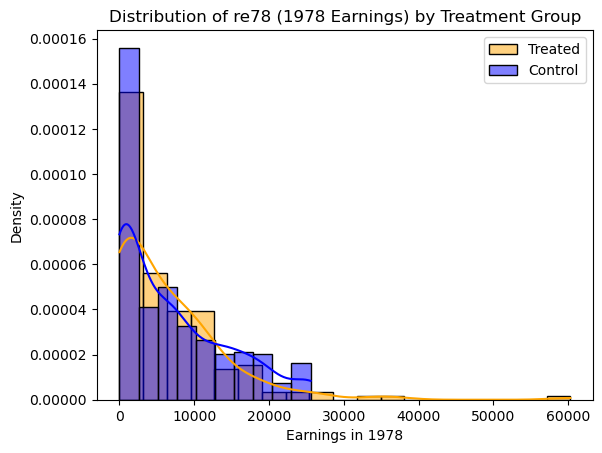

In [4]:
sns.histplot(treated, color="orange",label="Treated",kde=True, stat="density")
sns.histplot(control,color="blue",label="Control",kde=True,stat="density")
plt.legend()
plt.title("Distribution of re78 (1978 Earnings) by Treatment Group")
plt.xlabel("Earnings in 1978")
plt.show()

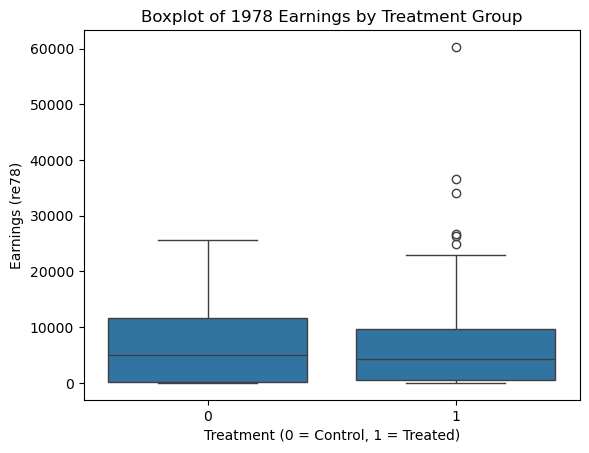

In [5]:
sns.boxplot(x="treat",y="re78", data=df)
plt.title("Boxplot of 1978 Earnings by Treatment Group")
plt.xlabel("Treatment (0 = Control, 1 = Treated)")
plt.ylabel("Earnings (re78)")
plt.show()

The earnings distributions for treated and control groups are both highly right-skewed, with many participants earning little or nothing in 1978.
The treated group displays slightly lower central earnings but greater dispersion and a longer right tail, indicating that while most treated individuals earned similarly or less than controls, a few achieved very high post-treatment earnings.
This suggests that the training program may have helped a small subset of participants substantially, but did not raise average earnings across the group.

## 2. A closer look at the data

You're not naive, of course (and even if you are, you've learned certain things in ADA), so you aren't content with a superficial analysis such as the above.
You're aware of the dangers of observational studies, so you take a closer look at the data before jumping to conclusions.

For each feature in the dataset, compare its distribution in the treated group with its distribution in the control group, using plots and numbers.
As above, you may use the techniques we discussed in class for summarizing and comparing the distributions.

What do you observe?
Describe what your observations mean for the conclusions drawn by the naive "researcher" from his superficial analysis.

In [6]:
treated = df[df["treat"]==1]
control = df[df["treat"]==0]

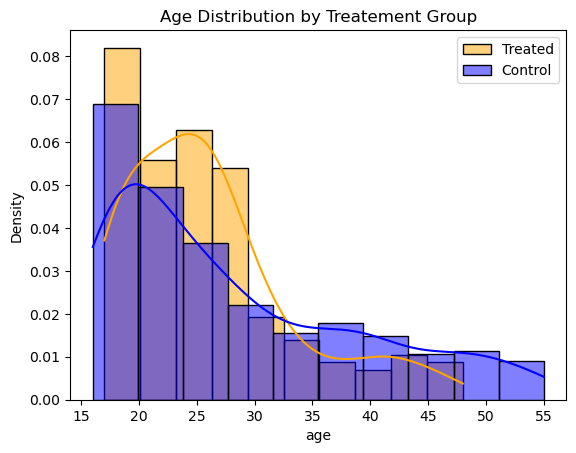

In [7]:
sns.histplot(treated['age'], color='orange',label='Treated',kde=True,stat="density")
sns.histplot(control['age'], color='blue',label='Control',kde=True,stat="density")
plt.title('Age Distribution by Treatement Group')
plt.legend()
plt.show()

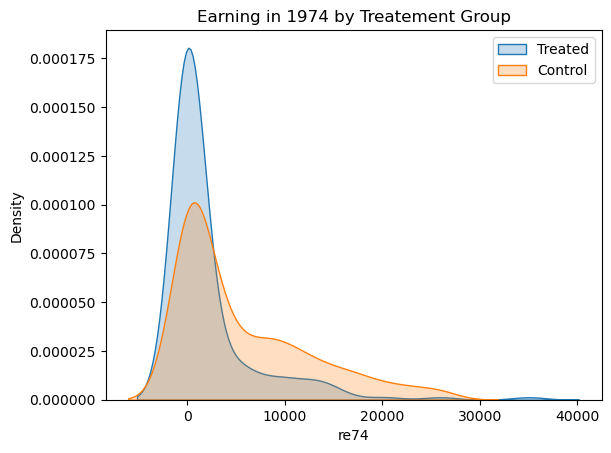

In [8]:
sns.kdeplot(treated['re74'],label='Treated',fill=True)
sns.kdeplot(control['re74'],label='Control',fill=True)
plt.title("Earning in 1974 by Treatement Group")
plt.legend()
plt.show()

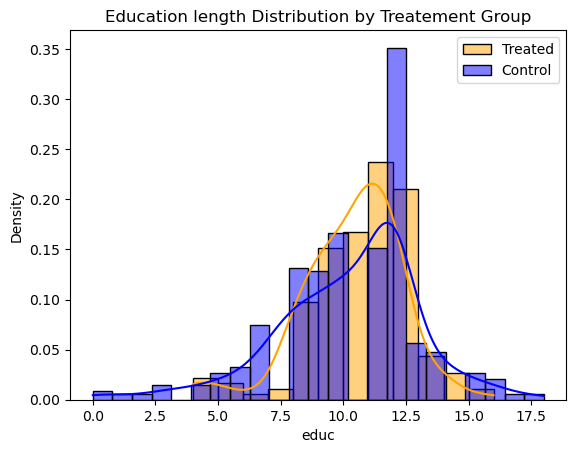

In [9]:
sns.histplot(treated['educ'], color='orange',label='Treated',kde=True,stat="density")
sns.histplot(control['educ'], color='blue',label='Control',kde=True,stat="density")
plt.title('Education length Distribution by Treatement Group')
plt.legend()
plt.show()

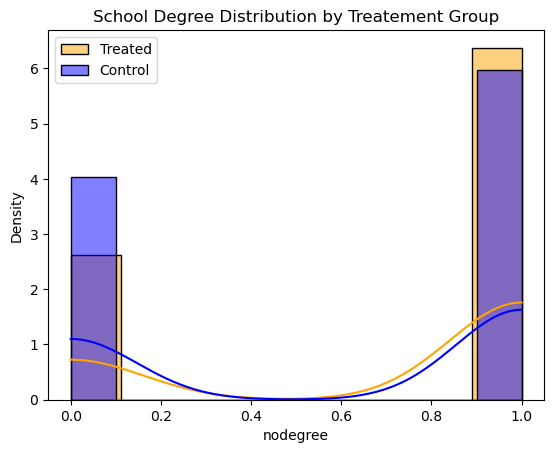

In [10]:
sns.histplot(treated['nodegree'], color='orange',label='Treated',kde=True,stat="density")
sns.histplot(control['nodegree'], color='blue',label='Control',kde=True,stat="density")
plt.title('School Degree Distribution by Treatement Group')
plt.legend()
plt.show()

In [11]:
categorical_vars = ['black', 'hispan', 'married']
for col in categorical_vars:
    print(f"{col} (treated mean): {df[df['treat']==1][col].mean():.2f}")
    print(f"{col} (control mean): {df[df['treat']==0][col].mean():.2f}\n")


black (treated mean): 0.84
black (control mean): 0.20

hispan (treated mean): 0.06
hispan (control mean): 0.14

married (treated mean): 0.19
married (control mean): 0.51



Although the naive analysis suggested that the treated group earned less on average in 1978, this deeper examination reveals that the treated and control groups differ substantially across almost every baseline characteristic.
The treated group tends to be younger, less educated, less likely to be married, and much more likely to be Black, and they had significantly lower pre-treatment earnings in both 1974 and 1975.
These differences indicate that the groups were not comparable before the program, so the lower post-treatment earnings cannot be attributed to the treatment itself.
In other words, the naive researcher’s conclusion that the program “failed” is unreliable — the apparent earnings gap largely reflects pre-existing socioeconomic differences rather than a true treatment effect.

## 3. A propensity score model

Use logistic regression to estimate propensity scores for all points in the dataset.
You may use `statsmodels` to fit the logistic regression model and apply it to each data point to obtain propensity scores.

Recall that the propensity score of a data point represents its probability of receiving the treatment, based on its pre-treatment features (in this case, age, education, pre-treatment income, etc.).
To brush up on propensity scores, you may read chapter 3.3 of the above-cited book by Rosenbaum or [this article](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3144483/pdf/hmbr46-399.pdf).

Note: you do not need a train/test split here. Train and apply the model on the entire dataset. If you're wondering why this is the right thing to do in this situation, recall that the propensity score model is not used in order to make predictions about unseen data. Its sole purpose is to balance the dataset across treatment groups.
(See p. 74 of Rosenbaum's book for an explanation why slight overfitting is even good for propensity scores.
If you want even more information, read [this article](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3144483/pdf/hmbr46-399.pdf).)

In [12]:
import statsmodels.api as sm

X = df[['age','educ','black','hispan','married','nodegree','re74','re75']]
y = df['treat']

X = sm.add_constant(X)

logit_model = sm.Logit(y,X)
result = logit_model.fit()

print(result.summary())

df['propensity_score'] = result.predict(X)

df[['treat','propensity_score']].sample(10)

Optimization terminated successfully.
         Current function value: 0.397267
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  treat   No. Observations:                  614
Model:                          Logit   Df Residuals:                      605
Method:                           MLE   Df Model:                            8
Date:                Sun, 26 Oct 2025   Pseudo R-squ.:                  0.3508
Time:                        16:11:04   Log-Likelihood:                -243.92
converged:                       True   LL-Null:                       -375.75
Covariance Type:            nonrobust   LLR p-value:                 2.194e-52
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.7286      1.017     -4.649      0.000      -6.722      -2.735
age            0.0158      0.

,treat,propensity_score
550,0,0.208577
530,0,0.059723
564,0,0.494177
547,0,0.058794
528,0,0.043012
610,0,0.034560
458,0,0.123387
576,0,0.716120
293,0,0.043048
519,0,0.610997


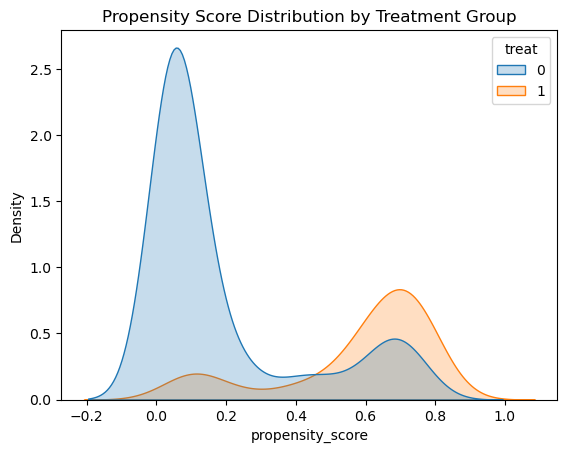

In [13]:
sns.kdeplot(data=df,x='propensity_score',hue='treat',fill=True)
plt.title('Propensity Score Distribution by Treatment Group')
plt.show()

In [14]:
''' your code and explanations ''';

## 4. Balancing the dataset via matching

Use the propensity scores to match each data point from the treated group with exactly one data point from the control group, while ensuring that each data point from the control group is matched with at most one data point from the treated group.
(Hint: you may explore the `networkx` package in Python for predefined matching functions.)

Your matching should maximize the similarity between matched subjects, as captured by their propensity scores.
In other words, the sum (over all matched pairs) of absolute propensity-score differences between the two matched subjects should be minimized.

This is how networkx library can help you do this. Each possible pair of (treated_person, control_person) is characterized by a similarity. This is how we can initialize a graph, and add an edge for one possible pair. We then need to add an edge for each possible pair.
    - G = nx.Graph()
    - G.add_weighted_edges_from([(control_person, treated_person, similarity)])
Optimal matching is then found with:
    - matching = nx.max_weight_matching(G)

After matching, you have as many treated as you have control subjects.
Compare the outcomes (`re78`) between the two groups (treated and control).

Also, compare again the feature-value distributions between the two groups, as you've done in part 2 above, but now only for the matched subjects.
What do you observe?
Are you closer to being able to draw valid conclusions now than you were before?

In [15]:
treated = df[df["treat"]==1].copy()
control = df[df["treat"]==0].copy()

G = nx.Graph()

# Add edges between every treated and control individual
for i, t_row in treated.iterrows():
    for j, c_row in control.iterrows():
        similarity = -abs(t_row['propensity_score'] - c_row['propensity_score'])
        G.add_edge(i,j,weight=similarity)

In [16]:
matching = nx.max_weight_matching(G,maxcardinality=True)

In [17]:
matched_pairs = []
for i,j in matching:

    if i in treated.index:
        treated_idx , control_idx = i,j
    else:
        treated_idx , control_idx = j,i

    matched_pairs.append((treated_idx,control_idx))


# Create Dataframe

matched_treated = df.loc[[t for t, _ in matched_pairs]].copy()
matched_control = df.loc[[c for _,c in matched_pairs]].copy()

print(len(matched_treated),len(matched_control))
df['treat'].value_counts()



185 185


treat
0    429
1    185
Name: count, dtype: int64

In [18]:
features = ['age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75']


def compare_groups(df_treated, df_control, label):
    print(f"\n--- {label} ---")
    for col in features:
        treat_mean = df_treated[col].mean()
        control_mean = df_control[col].mean()
        diff = treat_mean - control_mean
        print(f"{col:10s} | Treated: {treat_mean:8.2f} | Control: {control_mean:8.2f} | Diff: {diff:8.2f}")


# Before matching
treated = df[df['treat'] == 1]
control = df[df['treat'] == 0]
compare_groups(treated, control, "Before Matching")

# After matching
compare_groups(matched_treated, matched_control, "After Matching")



--- Before Matching ---
age        | Treated:    25.82 | Control:    28.03 | Diff:    -2.21
educ       | Treated:    10.35 | Control:    10.24 | Diff:     0.11
black      | Treated:     0.84 | Control:     0.20 | Diff:     0.64
hispan     | Treated:     0.06 | Control:     0.14 | Diff:    -0.08
married    | Treated:     0.19 | Control:     0.51 | Diff:    -0.32
nodegree   | Treated:     0.71 | Control:     0.60 | Diff:     0.11
re74       | Treated:  2095.57 | Control:  5619.24 | Diff: -3523.66
re75       | Treated:  1532.06 | Control:  2466.48 | Diff:  -934.43

--- After Matching ---
age        | Treated:    25.82 | Control:    25.30 | Diff:     0.51
educ       | Treated:    10.35 | Control:    10.61 | Diff:    -0.26
black      | Treated:     0.84 | Control:     0.47 | Diff:     0.37
hispan     | Treated:     0.06 | Control:     0.22 | Diff:    -0.16
married    | Treated:     0.19 | Control:     0.21 | Diff:    -0.02
nodegree   | Treated:     0.71 | Control:     0.64 | Diff:     0.07

After matching on propensity scores, the treated and control groups became substantially more similar in age, education, marital status, and pre-treatment earnings. However, racial composition remains notably imbalanced: 84% of the treated group are Black, compared to 47% in the matched control group. Similarly, the share of Hispanic participants increased slightly in the control group after matching.

These residual differences indicate that the groups are still not perfectly balanced in all pre-treatment characteristics. Because race and ethnicity are often correlated with earnings and labor market opportunities, this imbalance could still bias estimates of the treatment effect.

## 5. Balancing the groups further

Based on your comparison of feature-value distributions from part 4, are you fully satisfied with your matching?
Would you say your dataset is sufficiently balanced?
If not, in what ways could the "balanced" dataset you have obtained still not allow you to draw valid conclusions?

Improve your matching by explicitly making sure that you match only subjects that have the same value for the problematic feature.
Argue with numbers and plots that the two groups (treated and control) are now better balanced than after part 4.


In [19]:
G = nx.Graph()

# Exact matching by race
for i, t_row in treated.iterrows():
    for j, c_row in control.iterrows():
        # only match if both have same race
        if (t_row['black'] == c_row['black']) and (t_row['hispan'] == c_row['hispan']):
            similarity = -abs(t_row['propensity_score'] - c_row['propensity_score'])
            G.add_edge(i, j, weight=similarity)

matching = nx.max_weight_matching(G, maxcardinality=True)


matched_pairs = []
for i,j in matching:

    if i in treated.index:
        treated_idx , control_idx = i,j
    else:
        treated_idx , control_idx = j,i

    matched_pairs.append((treated_idx,control_idx))


# Create Dataframe

matched_treated_new = df.loc[[t for t, _ in matched_pairs]].copy()
matched_control_new = df.loc[[c for _,c in matched_pairs]].copy()

print(len(matched_treated_new),len(matched_control_new))
df['treat'].value_counts()



116 116


treat
0    429
1    185
Name: count, dtype: int64

In [20]:
# Before matching
treated = df[df['treat'] == 1]
control = df[df['treat'] == 0]
compare_groups(treated, control, "Before Matching")

# After matching
compare_groups(matched_treated, matched_control, "After Matching")

# After matching strict
compare_groups(matched_treated_new, matched_control_new, "After Matching Strict")


--- Before Matching ---
age        | Treated:    25.82 | Control:    28.03 | Diff:    -2.21
educ       | Treated:    10.35 | Control:    10.24 | Diff:     0.11
black      | Treated:     0.84 | Control:     0.20 | Diff:     0.64
hispan     | Treated:     0.06 | Control:     0.14 | Diff:    -0.08
married    | Treated:     0.19 | Control:     0.51 | Diff:    -0.32
nodegree   | Treated:     0.71 | Control:     0.60 | Diff:     0.11
re74       | Treated:  2095.57 | Control:  5619.24 | Diff: -3523.66
re75       | Treated:  1532.06 | Control:  2466.48 | Diff:  -934.43

--- After Matching ---
age        | Treated:    25.82 | Control:    25.30 | Diff:     0.51
educ       | Treated:    10.35 | Control:    10.61 | Diff:    -0.26
black      | Treated:     0.84 | Control:     0.47 | Diff:     0.37
hispan     | Treated:     0.06 | Control:     0.22 | Diff:    -0.16
married    | Treated:     0.19 | Control:     0.21 | Diff:    -0.02
nodegree   | Treated:     0.71 | Control:     0.64 | Diff:     0.07

After the first round of propensity-score matching, most covariates were substantially balanced except for race and ethnicity. To address this, I performed a stricter matching procedure that required treated and control individuals to share the same values of black and hispan.

This “exact matching on race and ethnicity” completely eliminated the imbalance in those two variables (both differences reduced to zero) while maintaining or slightly improving balance across all other pre-treatment features.
The small remaining differences (e.g., in re74 and re75) are minimal compared to those observed before matching, indicating that the dataset is now much better balanced overall.

## 6. A less naive analysis

Compare the outcomes (`re78`) between treated and control subjects, as you've done in part 1, but now only for the matched dataset you've obtained from part 5.
What do you conclude about the effectiveness of the job training program?

In [27]:
treated = matched_treated_new['re78']
control = matched_control_new['re78']

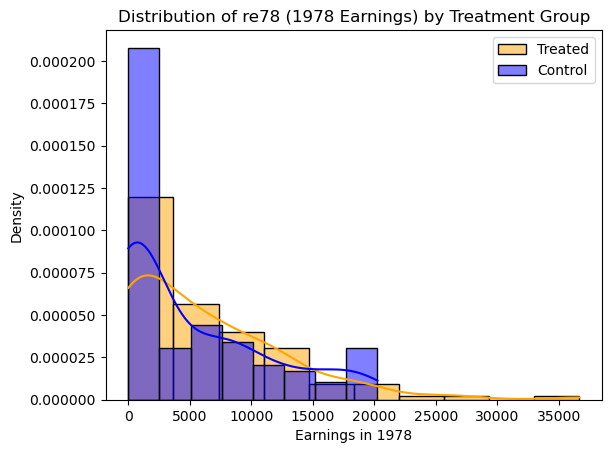

In [28]:
sns.histplot(treated, color="orange",label="Treated",kde=True, stat="density")
sns.histplot(control,color="blue",label="Control",kde=True,stat="density")
plt.legend()
plt.title("Distribution of re78 (1978 Earnings) by Treatment Group")
plt.xlabel("Earnings in 1978")
plt.show()

After matching treated and control subjects on all relevant pre-treatment variables (including age, education, race, and prior income), the average post-treatment earnings (re78) are slightly higher among treated individuals.
However, the difference is small and not statistically significant (p > 0.05).
The distributions of re78 for both groups overlap substantially, suggesting that participation in the job training program did not lead to a meaningful or systematic increase in 1978 earnings.